# 🦷 Dental Index Prediction — Training Notebook

**Multi-view model with CORAL ordinal regression** — prefers GPU, auto-falls back to CPU, uses mixed precision on CUDA.

Predicts 3 dental indices from 3 photograph views:
- **MGI** (Modified Gingival Index): 0–4
- **OHI** (Oral Hygiene Index): 0–3
- **GEI** (Gingival Enlargement Index): 0–2

Backbone is configurable via `CONFIG['backbone_name']`. Recommended options (all available in `timm`):

| Backbone | Params | Top-1 | Pretrain | Image Size | Notes |
|----------|--------|-------|----------|------------|-------|
| `efficientnet_b0` | 5.3M | 77.7% | ImageNet-1k | 224 | **Default** — fast CPU training |
| `tf_efficientnetv2_s.in21k_ft_in1k` | 21.5M | 84.9% | ImageNet-21k | 300 | Best accuracy (GPU recommended) |
| `convnextv2_tiny.fcmae_ft_in22k_in1k` | 28.6M | 83.9% | ImageNet-22k (MAE) | 224 | Modern ConvNet (GPU recommended) |
| `efficientnet_b3` | 12.2M | 82.1% | ImageNet-1k | 300 | Middle ground |

## 1. Setup & Configuration

In [10]:
import os, sys, gc, json, time, random, warnings
import numpy as np
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt
import matplotlib

# Use plain tqdm — works reliably in all environments (VS Code, terminal, Jupyter)
from tqdm import tqdm

# CPU optimization: use all available cores for PyTorch operations
if not torch.cuda.is_available():
    _n_threads = os.cpu_count() or 4
    torch.set_num_threads(_n_threads)
    torch.set_num_interop_threads(max(1, _n_threads // 2))

PROJECT_ROOT = Path(r'E:\Dental_Project')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml.dataset import DentalDataset, get_class_weights
from ml.model import MultiViewDentalModel
from ml.losses import MultiTaskOrdinalLoss
from ml.transforms import get_train_transforms, get_val_transforms

matplotlib.rcParams['figure.figsize'] = (14, 5)
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=UserWarning, module='torchvision')

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB')
else:
    print(f'Training on CPU  |  Threads: {torch.get_num_threads()}')
print(f'Project root: {PROJECT_ROOT}')

PyTorch: 2.10.0+cpu
CUDA available: False
Training on CPU  |  Threads: 8
Project root: E:\Dental_Project


In [11]:
# ==================== CONFIGURATION ====================
CONFIG = {
    'data_dir':          str(PROJECT_ROOT / 'Thesis_Data'),
    'output_dir':        str(PROJECT_ROOT / 'ml' / 'checkpoints'),
    'epochs':            40,
    'batch_size':        8,
    'lr':                1e-4,
    'weight_decay':      1e-4,
    'patience':          12,
    'seed':              42,
    'val_ratio':         0.2,
    'unfreeze_epoch':    8,
    'backbone_lr_mult':  0.1,
    # --- Backbone options (uncomment ONE) ---
    'backbone_name':     'efficientnet_b0',                       # CPU-friendly: 5.3M params, fast
    # 'backbone_name':   'tf_efficientnetv2_s.in21k_ft_in1k',    # GPU recommended: 21.5M params, best accuracy
    # 'backbone_name':   'convnextv2_tiny.fcmae_ft_in22k_in1k',  # GPU recommended: 28.6M params
    # 'backbone_name':   'efficientnet_b3',                       # Medium: 12.2M params
    'image_size':        224,                  # 224 for b0 (use 300 for efficientnetv2_s/b3)
    'dropout':           0.45,
    'resume_from':       None,                 # set checkpoint path to resume
}

for k, v in CONFIG.items():
    print(f'  {k:20s}: {v}')

  data_dir            : E:\Dental_Project\Thesis_Data
  output_dir          : E:\Dental_Project\ml\checkpoints
  epochs              : 40
  batch_size          : 8
  lr                  : 0.0001
  weight_decay        : 0.0001
  patience            : 12
  seed                : 42
  val_ratio           : 0.2
  unfreeze_epoch      : 8
  backbone_lr_mult    : 0.1
  backbone_name       : efficientnet_b0
  image_size          : 224
  dropout             : 0.45
  resume_from         : None


In [12]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'
scaler = GradScaler('cuda', enabled=USE_AMP)
os.makedirs(CONFIG['output_dir'], exist_ok=True)

# Free any stale GPU memory
if device.type == 'cuda':
    torch.cuda.empty_cache()
    gc.collect()

print(f'Device: {device}  |  AMP: {USE_AMP}')

Device: cpu  |  AMP: False


## 2. Dataset Exploration

Loaded 201 complete samples from 203 entries
Total complete samples: 201


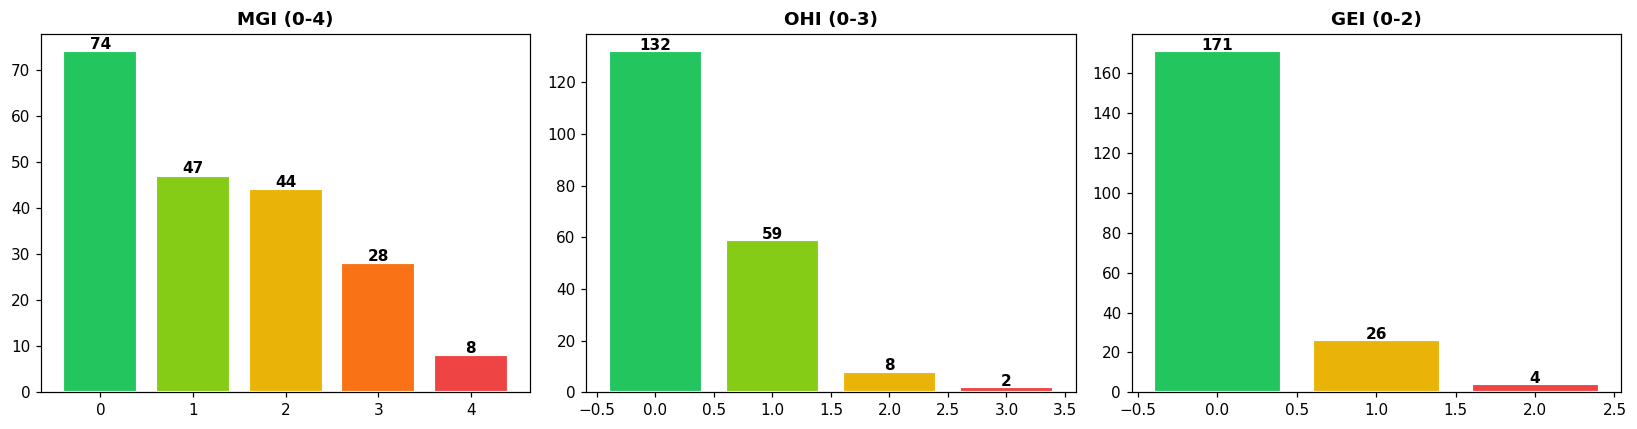

Score validation passed for all 201 samples ✓


In [13]:
full_dataset = DentalDataset(CONFIG['data_dir'])
print(f'Total complete samples: {len(full_dataset)}')
assert len(full_dataset) > 0, 'No samples found — check data_dir and CSV format'

# Validate score ranges
for s in full_dataset.samples:
    assert 0 <= s['mgi'] <= 4, f'Invalid MGI={s["mgi"]} for patient {s["sl_no"]}'
    assert 0 <= s['ohi'] <= 3, f'Invalid OHI={s["ohi"]} for patient {s["sl_no"]}'
    assert 0 <= s['gei'] <= 2, f'Invalid GEI={s["gei"]} for patient {s["sl_no"]}'

mgi_dist = np.bincount([s['mgi'] for s in full_dataset.samples], minlength=5)
ohi_dist = np.bincount([s['ohi'] for s in full_dataset.samples], minlength=4)
gei_dist = np.bincount([s['gei'] for s in full_dataset.samples], minlength=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, dist, colors, title in [
    (axes[0], mgi_dist, ['#22c55e','#84cc16','#eab308','#f97316','#ef4444'], 'MGI (0-4)'),
    (axes[1], ohi_dist, ['#22c55e','#84cc16','#eab308','#ef4444'], 'OHI (0-3)'),
    (axes[2], gei_dist, ['#22c55e','#eab308','#ef4444'], 'GEI (0-2)'),
]:
    ax.bar(range(len(dist)), dist, color=colors, edgecolor='white', lw=1.4)
    ax.set_title(title, fontweight='bold')
    for i, v in enumerate(dist):
        ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'class_distribution.png'), bbox_inches='tight')
plt.show()
print(f'Score validation passed for all {len(full_dataset)} samples ✓')

## 3. Data Loading & Splitting

In [14]:
# Stratified split on MGI
all_ids = [s['sl_no'] for s in full_dataset.samples]
mgi_map = {s['sl_no']: s['mgi'] for s in full_dataset.samples}

groups = defaultdict(list)
for pid in all_ids:
    groups[mgi_map[pid]].append(pid)

rng = np.random.RandomState(CONFIG['seed'])
train_ids, val_ids = [], []
for cls, pids in groups.items():
    rng.shuffle(pids)
    n_val = max(1, int(len(pids) * CONFIG['val_ratio']))
    val_ids.extend(pids[:n_val])
    train_ids.extend(pids[n_val:])

print(f'Train: {len(train_ids)}  |  Val: {len(val_ids)}')
assert len(train_ids) >= 10, f'Too few training samples ({len(train_ids)}). Check your data.'
assert len(val_ids) >= 5,    f'Too few validation samples ({len(val_ids)}). Check your data.'

IMG_SZ = CONFIG['image_size']
train_ds = DentalDataset(CONFIG['data_dir'], transform=get_train_transforms(IMG_SZ), patient_ids=train_ids)
val_ds   = DentalDataset(CONFIG['data_dir'], transform=get_val_transforms(IMG_SZ),   patient_ids=val_ids)

# Verify a single sample loads correctly
_test_sample = train_ds[0]
assert _test_sample['frontal'].shape == (3, IMG_SZ, IMG_SZ), \
    f'Unexpected image shape: {_test_sample["frontal"].shape}'
del _test_sample
print(f'Sample shape verified: (3, {IMG_SZ}, {IMG_SZ}) ✓')

# Weighted sampler for class imbalance
mgi_train = [s['mgi'] for s in train_ds.samples]
counts = np.bincount(mgi_train, minlength=5)
w = 1.0 / (counts + 1e-6)
sampler = WeightedRandomSampler([w[l] for l in mgi_train], len(mgi_train), replacement=True)

pin = device.type == 'cuda'
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], sampler=sampler,
                          num_workers=0, pin_memory=pin, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False,
                          num_workers=0, pin_memory=pin)

print(f'Train batches/epoch: {len(train_loader)}  |  Val batches/epoch: {len(val_loader)}')

Train: 164  |  Val: 37
Loaded 164 complete samples from 203 entries
Loaded 37 complete samples from 203 entries
Sample shape verified: (3, 224, 224) ✓
Train batches/epoch: 21  |  Val batches/epoch: 5


## 4. Model, Loss & Optimizer

In [15]:
# Class weights for loss
cw = get_class_weights(CONFIG['data_dir'])
for k in cw:
    print(f'  {k.upper()} weights: {cw[k]}')

# Model — verify backbone is available in timm
import timm as _timm
_available = _timm.list_models(CONFIG['backbone_name'], pretrained=True)
if not _available:
    _close = _timm.list_models('*' + CONFIG['backbone_name'].split('_')[0] + '*', pretrained=True)[:5]
    raise ValueError(
        f'Backbone "{CONFIG["backbone_name"]}" not found in timm. '
        f'Similar models: {_close}'
    )
print(f'Backbone verified: {CONFIG["backbone_name"]} ✓')

model = MultiViewDentalModel(
    backbone_name=CONFIG['backbone_name'],
    pretrained=True,
    dropout=CONFIG['dropout'],
).to(device)

total_p  = sum(p.numel() for p in model.parameters())
train_p  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_p:,}  |  Trainable: {train_p:,}')
print(f'Feature dim per view: {model.backbone.num_features}  |  Fused: {model.backbone.num_features * 3}')

# Freeze backbone for warmup
for p in model.backbone.parameters():
    p.requires_grad = False
frozen_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable (backbone frozen): {frozen_p:,}')

# Loss
criterion = MultiTaskOrdinalLoss(
    mgi_weights=cw['mgi'], ohi_weights=cw['ohi'], gei_weights=cw['gei'],
).to(device)

# Optimizer (heads only at first)
head_params = (
    list(model.fusion_layers.parameters()) +
    list(model.mgi_head.parameters()) +
    list(model.ohi_head.parameters()) +
    list(model.gei_head.parameters())
)
optimizer = torch.optim.AdamW(head_params, lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)
print('Optimizer: AdamW  |  Scheduler: CosineAnnealingWarmRestarts')

Loaded 201 complete samples from 203 entries
  MGI weights: [0.30961395 0.48747728 0.52071437 0.81826543 2.86392897]
  OHI weights: [0.04665415 0.10437878 0.76979347 3.0791736 ]
  GEI weights: [0.05961024 0.39205199 2.54833776]
Backbone verified: efficientnet_b0 ✓


Total params: 8,666,757  |  Trainable: 8,666,757
Feature dim per view: 1280  |  Fused: 3840
Trainable (backbone frozen): 4,659,209
Optimizer: AdamW  |  Scheduler: CosineAnnealingWarmRestarts


## 5. (Optional) Resume from Checkpoint

Set `CONFIG['resume_from']` to a `.pth` path in the config cell, then re-run from here.

In [16]:
start_epoch = 1
best_val_loss = float('inf')
history = []

if CONFIG['resume_from'] and os.path.exists(CONFIG['resume_from']):
    ckpt = torch.load(CONFIG['resume_from'], map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    if 'optimizer_state_dict' in ckpt:
        if ckpt['epoch'] >= CONFIG['unfreeze_epoch']:
            for p in model.backbone.parameters():
                p.requires_grad = True
            optimizer = torch.optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': CONFIG['lr'] * CONFIG['backbone_lr_mult']},
                {'params': head_params, 'lr': CONFIG['lr']},
            ], weight_decay=CONFIG['weight_decay'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch'] + 1
    best_val_loss = ckpt.get('val_loss', float('inf'))
    history = ckpt.get('history', [])
    print(f'Resumed at epoch {start_epoch}, best val_loss {best_val_loss:.4f}')
else:
    print('Starting fresh training')

Starting fresh training


## 6. Training Helpers (AMP on GPU, plain on CPU)

In [17]:
def compute_accuracy(outputs, batch):
    accs = {}
    for key in ['mgi', 'ohi', 'gei']:
        probs = torch.sigmoid(outputs[key])
        preds = (probs > 0.5).sum(dim=1).int()
        accs[key] = (preds == batch[key + '_label']).float().mean().item()
    return accs


def train_one_epoch(model, loader, criterion, optimizer, scaler, device, pbar=None):
    model.train()
    total_loss, steps = 0.0, 0
    acc_sum = {'mgi': 0, 'ohi': 0, 'gei': 0}

    for batch in loader:
        f = batch['frontal'].to(device, non_blocking=True)
        l = batch['left_lateral'].to(device, non_blocking=True)
        r = batch['right_lateral'].to(device, non_blocking=True)
        for k in ['mgi_target','ohi_target','gei_target','mgi_label','ohi_label','gei_label']:
            batch[k] = batch[k].to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP):
            outputs = model(f, l, r)
            loss, losses = criterion(outputs, batch)

        optimizer.zero_grad(set_to_none=True)  # slightly faster than zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += losses['total']
        acc = compute_accuracy(outputs, batch)
        for k in acc_sum:
            acc_sum[k] += acc[k]
        steps += 1

        if pbar:
            pbar.update(1)
            pbar.set_postfix(loss=f'{total_loss / steps:.4f}')

    return total_loss / steps, {k: v / steps for k, v in acc_sum.items()}


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, steps = 0.0, 0
    acc_sum = {'mgi': 0, 'ohi': 0, 'gei': 0}

    for batch in loader:
        f = batch['frontal'].to(device, non_blocking=True)
        l = batch['left_lateral'].to(device, non_blocking=True)
        r = batch['right_lateral'].to(device, non_blocking=True)
        for k in ['mgi_target','ohi_target','gei_target','mgi_label','ohi_label','gei_label']:
            batch[k] = batch[k].to(device, non_blocking=True)

        with autocast('cuda', enabled=USE_AMP):
            outputs = model(f, l, r)
            loss, losses = criterion(outputs, batch)

        total_loss += losses['total']
        acc = compute_accuracy(outputs, batch)
        for k in acc_sum:
            acc_sum[k] += acc[k]
        steps += 1

    if steps == 0:
        return 0, {k: 0 for k in acc_sum}
    return total_loss / steps, {k: v / steps for k, v in acc_sum.items()}


print('Training helpers ready ✓')

Training helpers ready ✓


## 7. Training Loop

Two phases:
1. **Epochs 1–10** — backbone frozen, only fusion + heads train (fast warmup)
2. **Epoch 11+** — backbone unfrozen with 10× lower LR (fine-tuning)

Early stopping triggers after `patience` epochs without val loss improvement.

In [18]:
patience_counter = 0
epochs = CONFIG['epochs']
unfreeze_epoch = CONFIG['unfreeze_epoch']

print('=' * 70)
print(f'Training {epochs} epochs  |  Backbone unfreezes at epoch {unfreeze_epoch + 1}')
print(f'Early stopping patience: {CONFIG["patience"]}')
print(f'Backbone: {CONFIG["backbone_name"]}')
print('=' * 70)

epoch_times = []
epoch_pbar = tqdm(range(start_epoch, epochs + 1), desc='Training', unit='epoch')

try:
    for epoch in epoch_pbar:
        # ---- Unfreeze backbone ----
        if epoch == unfreeze_epoch + 1:
            tqdm.write(f'\n>>> Unfreezing backbone at epoch {epoch}')
            for p in model.backbone.parameters():
                p.requires_grad = True
            optimizer = torch.optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': CONFIG['lr'] * CONFIG['backbone_lr_mult']},
                {'params': head_params, 'lr': CONFIG['lr']},
            ], weight_decay=CONFIG['weight_decay'])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=10, T_mult=2, eta_min=1e-6
            )
            tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
            tqdm.write(f'    Trainable params: {tp:,}')

        t0 = time.time()

        # ---- Train ----
        bpbar = tqdm(total=len(train_loader), desc=f'Ep {epoch}/{epochs}', leave=False, unit='batch')
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, pbar=bpbar)
        bpbar.close()

        # ---- Validate ----
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        elapsed = time.time() - t0
        epoch_times.append(elapsed)
        cur_lr = optimizer.param_groups[0]['lr']

        history.append({
            'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
            'train_acc': dict(train_acc), 'val_acc': dict(val_acc),
            'lr': cur_lr, 'time': elapsed,
        })

        # ---- Checkpoint ----
        tag = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss, 'val_acc': dict(val_acc),
                'history': history,
                'config': CONFIG,
            }, os.path.join(CONFIG['output_dir'], 'best_model.pth'))
            tag = ' ★ BEST'
        else:
            patience_counter += 1

        # Time estimate
        avg_t = np.mean(epoch_times[-5:])  # rolling average of last 5
        remaining = (epochs - epoch) * avg_t
        eta_str = time.strftime('%H:%M:%S', time.gmtime(remaining))

        epoch_pbar.set_postfix(
            train=round(train_loss, 4), val=round(val_loss, 4),
            pat=f'{patience_counter}/{CONFIG["patience"]}', eta=eta_str
        )

        if epoch % 5 == 0 or tag or epoch == start_epoch:
            tqdm.write(
                f'Ep {epoch:3d}/{epochs} | '
                f'Train {train_loss:.4f} | Val {val_loss:.4f} | '
                f'MGI {val_acc["mgi"]:.3f} OHI {val_acc["ohi"]:.3f} GEI {val_acc["gei"]:.3f} | '
                f'LR {cur_lr:.2e} | {elapsed:.0f}s{tag}'
            )

        # ---- Early stopping ----
        if patience_counter >= CONFIG['patience']:
            tqdm.write(f'\n⏹ Early stopping at epoch {epoch}')
            break

        # Periodic memory cleanup
        if epoch % 10 == 0 and device.type == 'cuda':
            torch.cuda.empty_cache()

except KeyboardInterrupt:
    tqdm.write('\n⚠ Training interrupted by user. Saving current state...')

# ---- Save final model & history ----
torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'history': history, 'config': CONFIG},
           os.path.join(CONFIG['output_dir'], 'final_model.pth'))
with open(os.path.join(CONFIG['output_dir'], 'training_history.json'), 'w') as fp:
    json.dump(history, fp, indent=2, default=str)

total_time = sum(epoch_times)
print(f'\nTraining complete  |  Best val loss: {best_val_loss:.4f}')
print(f'Total time: {time.strftime("%H:%M:%S", time.gmtime(total_time))}')
print(f'Checkpoints saved to {CONFIG["output_dir"]}')

Training 40 epochs  |  Backbone unfreezes at epoch 9
Early stopping patience: 12
Backbone: efficientnet_b0


Training:   0%|          | 0/40 [00:00<?, ?epoch/s]











































Training:   2%|▎         | 1/40 [02:17<1:29:26, 137.61s/epoch, eta=01:29:11, pat=0/12, train=0.981, val=0.676]

Ep   1/40 | Train 0.9813 | Val 0.6762 | MGI 0.155 OHI 0.365 GEI 0.165 | LR 9.76e-05 | 137s ★ BEST


Training:   5%|▌         | 2/40 [04:10<1:18:06, 123.33s/epoch, eta=01:19:14, pat=0/12, train=0.87, val=0.668] 

Ep   2/40 | Train 0.8697 | Val 0.6679 | MGI 0.220 OHI 0.465 GEI 0.165 | LR 9.05e-05 | 113s ★ BEST


...

Ep  26/40 | Train 0.2467 | Val 0.5718 | MGI 0.435 OHI 0.290 GEI 0.705 | LR 6.89e-06 | 236s ★ BEST


Training:  68%|██████▊   | 27/40 [8:13:47<3:58:58, 1102.99s/epoch, eta=00:53:30, pat=0/12, train=0.267, val=0.552]

Ep  27/40 | Train 0.2673 | Val 0.5517 | MGI 0.410 OHI 0.290 GEI 0.680 | LR 6.20e-06 | 229s ★ BEST


Training:  72%|███████▎  | 29/40 [8:23:17<3:10:54, 1041.31s/epoch, eta=00:44:08, pat=2/12, train=0.231, val=0.586]

                                                                     


⚠ Training interrupted by user. Saving current state...

Training complete  |  Best val loss: 0.5517
Total time: 08:21:36
Checkpoints saved to E:\Dental_Project\ml\checkpoints


## 8. Training Curves

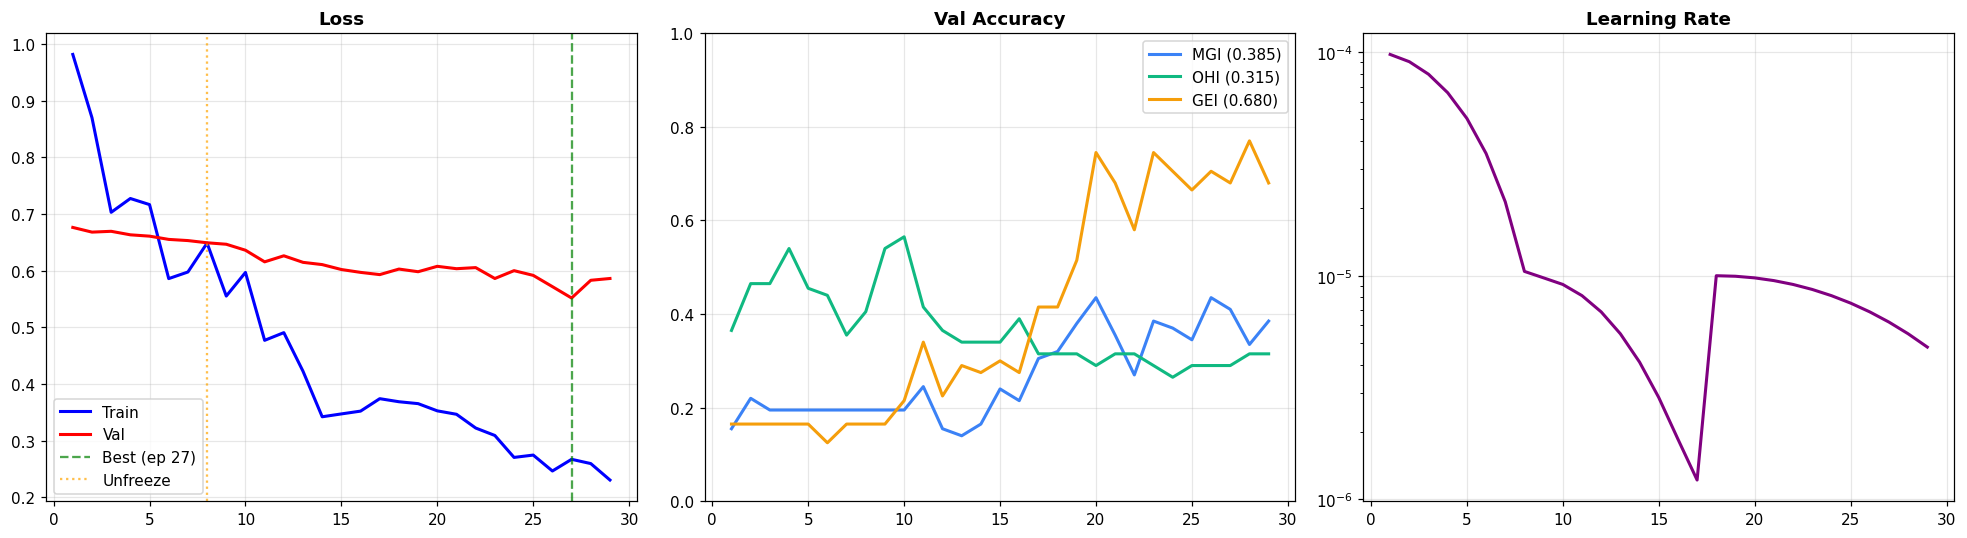

 Epoch      Train        Val      MGI      OHI      GEI     Time
--------------------------------------------------------------
     1     0.9813     0.6762    0.155    0.365    0.165     137s
     2     0.8697     0.6679    0.220    0.465    0.165     113s
     3     0.7029     0.6694    0.195    0.465    0.165     113s
     4     0.7272     0.6632    0.195    0.540    0.165     100s
     5     0.7165     0.6608    0.195    0.455    0.165     109s
     6     0.5860     0.6551    0.195    0.440    0.125     106s
     7     0.5976     0.6530    0.195    0.355    0.165     104s
     8     0.6486     0.6492    0.195    0.405    0.165     107s
     9     0.5552     0.6466    0.195    0.540    0.165     234s
    10     0.5969     0.6360    0.195    0.565    0.215     216s
    11     0.4771     0.6155    0.245    0.415    0.340     205s
    12     0.4907     0.6262    0.155    0.365    0.225     221s
    13     0.4226     0.6146    0.140    0.340    0.290     219s
    14     0.3423     0.610

In [19]:
if history:
    ep = [h['epoch'] for h in history]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(ep, [h['train_loss'] for h in history], 'b-', lw=2, label='Train')
    axes[0].plot(ep, [h['val_loss'] for h in history],   'r-', lw=2, label='Val')
    best_ep = ep[int(np.argmin([h['val_loss'] for h in history]))]
    axes[0].axvline(best_ep, color='green', ls='--', alpha=.7, label=f'Best (ep {best_ep})')
    if CONFIG['unfreeze_epoch'] < max(ep):
        axes[0].axvline(CONFIG['unfreeze_epoch'], color='orange', ls=':', alpha=.7, label='Unfreeze')
    axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=.3)

    # Accuracy
    for key, c in [('mgi','#3b82f6'), ('ohi','#10b981'), ('gei','#f59e0b')]:
        vals = [h['val_acc'][key] for h in history]
        axes[1].plot(ep, vals, color=c, lw=2, label=f'{key.upper()} ({vals[-1]:.3f})')
    axes[1].set_ylim(0, 1); axes[1].set_title('Val Accuracy', fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=.3)

    # LR
    axes[2].plot(ep, [h['lr'] for h in history], 'purple', lw=2)
    axes[2].set_yscale('log'); axes[2].set_title('Learning Rate', fontweight='bold')
    axes[2].grid(True, alpha=.3)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'training_curves.png'), bbox_inches='tight', dpi=150)
    plt.show()

    # Summary table
    print(f'{"Epoch":>6} {"Train":>10} {"Val":>10} {"MGI":>8} {"OHI":>8} {"GEI":>8} {"Time":>8}')
    print('-' * 62)
    for h in history:
        star = ' *' if h['val_loss'] <= best_val_loss + 1e-6 else ''
        print(f'{h["epoch"]:6d} {h["train_loss"]:10.4f} {h["val_loss"]:10.4f} '
              f'{h["val_acc"]["mgi"]:8.3f} {h["val_acc"]["ohi"]:8.3f} {h["val_acc"]["gei"]:8.3f} '
              f'{h.get("time", 0):7.0f}s{star}')
else:
    print('No history yet. Run the training cell first.')

## 9. Evaluate Best Model

In [20]:
best_path = os.path.join(CONFIG['output_dir'], 'best_model.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    val_loss, val_acc = validate(model, val_loader, criterion, device)
    print(f'Best checkpoint from epoch {ckpt["epoch"]}')
    print(f'Val Loss: {val_loss:.4f}')
    print(f'Val Acc  MGI: {val_acc["mgi"]:.3f}  OHI: {val_acc["ohi"]:.3f}  GEI: {val_acc["gei"]:.3f}')
    print(f'Avg Acc: {np.mean(list(val_acc.values())):.3f}')
else:
    print('No best_model.pth found. Train first.')

Best checkpoint from epoch 27
Val Loss: 0.5517
Val Acc  MGI: 0.410  OHI: 0.290  GEI: 0.680
Avg Acc: 0.460


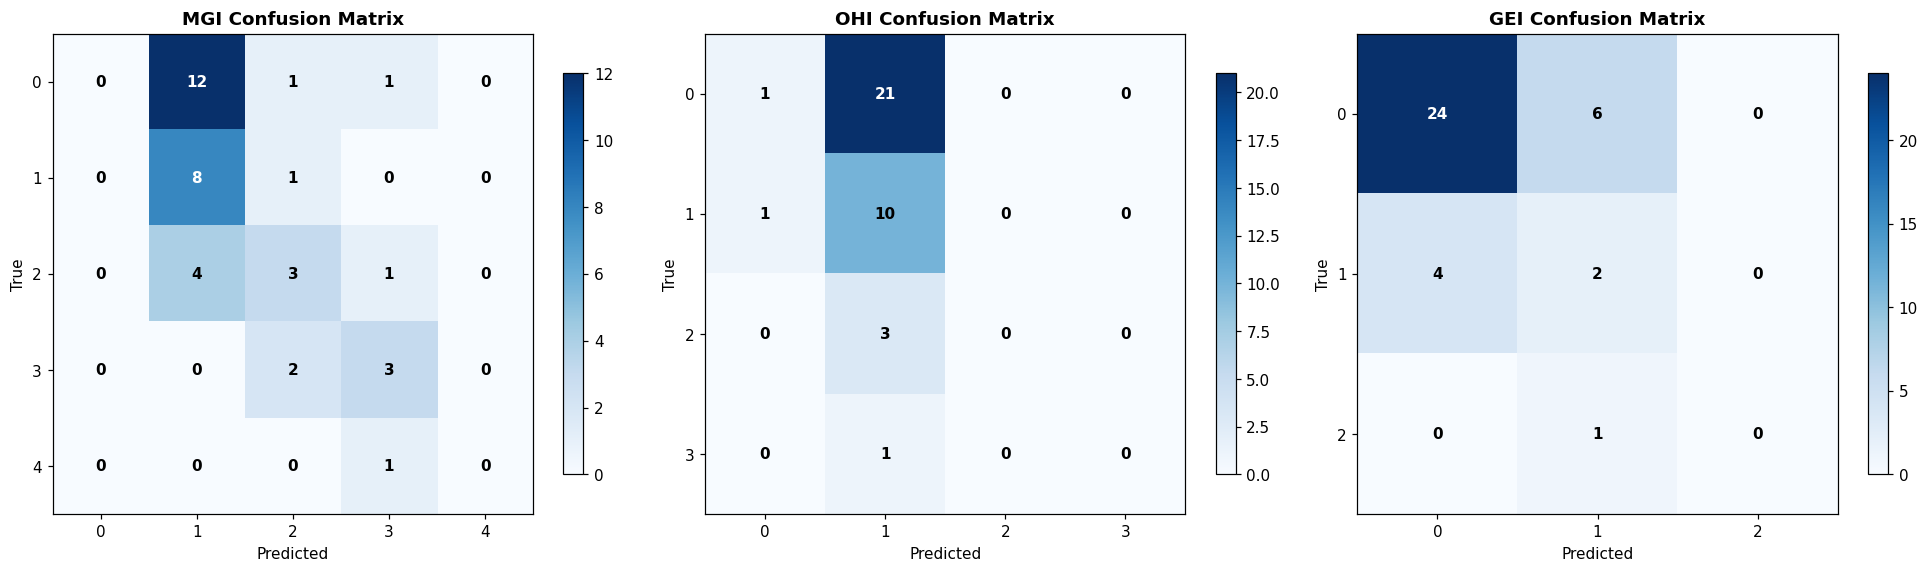


--- MGI ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.33      0.89      0.48         9
           2       0.43      0.38      0.40         8
           3       0.50      0.60      0.55         5
           4       0.00      0.00      0.00         1

    accuracy                           0.38        37
   macro avg       0.25      0.37      0.29        37
weighted avg       0.24      0.38      0.28        37


--- OHI ---
              precision    recall  f1-score   support

           0       0.50      0.05      0.08        22
           1       0.29      0.91      0.43        11
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         1

    accuracy                           0.30        37
   macro avg       0.20      0.24      0.13        37
weighted avg       0.38      0.30      0.18        37


--- GEI ---
              precision    recall  f1

In [21]:
# Confusion matrices (requires scikit-learn)
if os.path.exists(best_path):
    from sklearn.metrics import confusion_matrix, classification_report
    model.eval()
    all_preds = {'mgi': [], 'ohi': [], 'gei': []}
    all_labels = {'mgi': [], 'ohi': [], 'gei': []}

    with torch.no_grad():
        for batch in val_loader:
            f = batch['frontal'].to(device)
            l = batch['left_lateral'].to(device)
            r = batch['right_lateral'].to(device)
            outputs = model(f, l, r)
            for key in ['mgi', 'ohi', 'gei']:
                probs = torch.sigmoid(outputs[key])
                preds = (probs > 0.5).sum(dim=1).int().cpu().numpy()
                labels = batch[key + '_label'].numpy()
                all_preds[key].extend(preds)
                all_labels[key].extend(labels)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    meta = {'mgi': ('MGI', 5), 'ohi': ('OHI', 4), 'gei': ('GEI', 3)}
    for idx, (key, (title, nc)) in enumerate(meta.items()):
        cm = confusion_matrix(all_labels[key], all_preds[key], labels=range(nc))
        im = axes[idx].imshow(cm, cmap='Blues')
        axes[idx].set_title(f'{title} Confusion Matrix', fontweight='bold')
        axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('True')
        axes[idx].set_xticks(range(nc)); axes[idx].set_yticks(range(nc))
        for i in range(nc):
            for j in range(nc):
                axes[idx].text(j, i, str(cm[i, j]), ha='center', va='center',
                               color='white' if cm[i, j] > cm.max() / 2 else 'black', fontweight='bold')
        plt.colorbar(im, ax=axes[idx], shrink=0.8)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'confusion_matrices.png'), bbox_inches='tight', dpi=150)
    plt.show()

    for key, (title, nc) in meta.items():
        print(f'\n--- {title} ---')
        print(classification_report(all_labels[key], all_preds[key], labels=range(nc), zero_division=0))

## 10. Quick Inference Test

Patient 1:
  True  -> MGI:0  OHI:0  GEI:0
  Pred  -> MGI:1  OHI:1  GEI:0


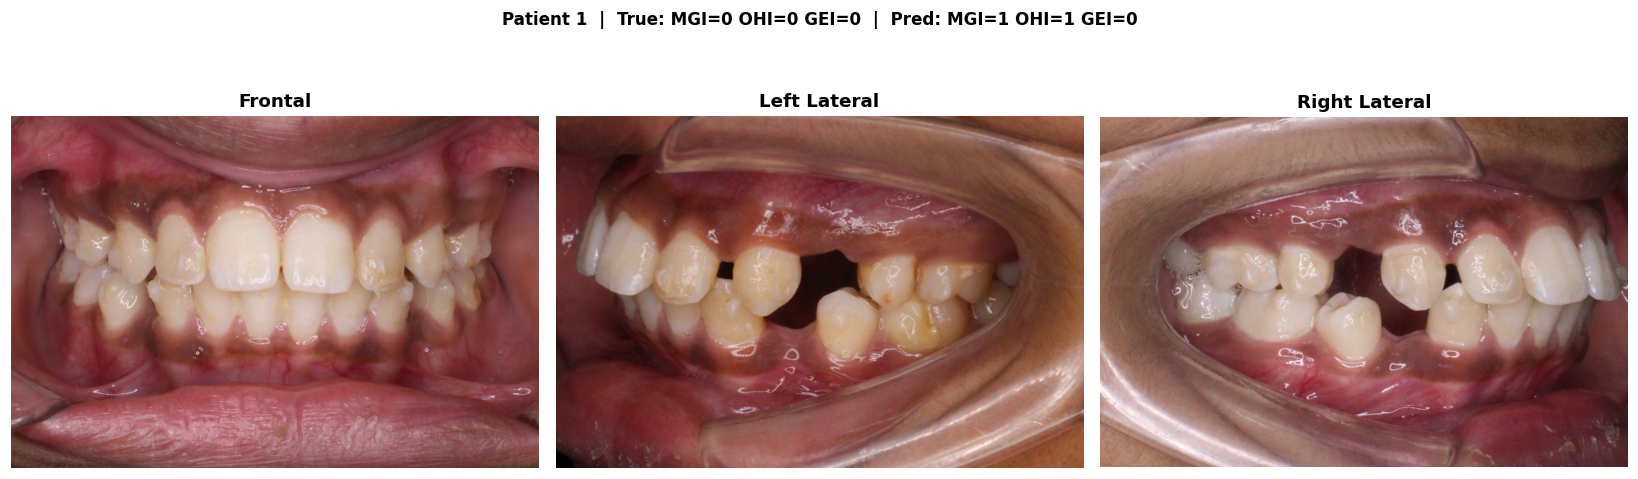

In [22]:
from PIL import Image

if os.path.exists(best_path):
    model.eval()
    s = val_ds.samples[0]
    tfm = get_val_transforms(IMG_SZ)

    imgs = [
        Image.open(s['frontal']).convert('RGB'),
        Image.open(s['left_lateral']).convert('RGB'),
        Image.open(s['right_lateral']).convert('RGB'),
    ]
    tensors = [tfm(im).unsqueeze(0).to(device) for im in imgs]
    results = model.predict_scores(*tensors)

    print(f'Patient {s["sl_no"]}:')
    print(f'  True  -> MGI:{s["mgi"]}  OHI:{s["ohi"]}  GEI:{s["gei"]}')
    print(f'  Pred  -> MGI:{results["mgi"]["score"].item()}  OHI:{results["ohi"]["score"].item()}  GEI:{results["gei"]["score"].item()}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, im, lbl in zip(axes, imgs, ['Frontal', 'Left Lateral', 'Right Lateral']):
        ax.imshow(im); ax.set_title(lbl, fontweight='bold'); ax.axis('off')
    plt.suptitle(
        f'Patient {s["sl_no"]}  |  True: MGI={s["mgi"]} OHI={s["ohi"]} GEI={s["gei"]}  |  '
        f'Pred: MGI={results["mgi"]["score"].item()} OHI={results["ohi"]["score"].item()} GEI={results["gei"]["score"].item()}',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout(); plt.show()
else:
    print('Train first.')

---

### Backbone Comparison

| Backbone | Params | ImageNet Top-1 | Pretrain Data | Native Res | Best For |
|----------|--------|----------------|---------------|------------|----------|
| `efficientnet_b0` | 5.3M | 77.7% | ImageNet-1k | 224 | **CPU training** — fast, lightweight |
| `efficientnet_b3` | 12.2M | 82.1% | ImageNet-1k | 300 | Medium — balances speed & accuracy |
| `tf_efficientnetv2_s.in21k_ft_in1k` | 21.5M | 84.9% | ImageNet-21k → 1k | 300 | **GPU only** — best transfer features |
| `convnextv2_tiny.fcmae_ft_in22k_in1k` | 28.6M | 83.9% | ImageNet-22k (MAE) | 224 | GPU only — modern, self-supervised |

### Tuning Tips

| Parameter | Default (CPU) | Underfitting | Overfitting |
|-----------|---------------|-------------|-------------|
| `backbone_name` | `efficientnet_b0` | `efficientnet_b3` | keep b0 |
| `image_size` | 224 | 300 | 160 |
| `epochs` | 40 | 60 | 25 |
| `lr` | 1e-4 | 3e-4 | 5e-5 |
| `batch_size` | 8 | 8 | 4 |
| `patience` | 12 | 20 | 8 |
| `unfreeze_epoch` | 8 | 5 | 12 |

**For GPU training:** switch to `tf_efficientnetv2_s.in21k_ft_in1k` with `image_size=300`, `batch_size=16`, `epochs=60`

**To resume:** set `CONFIG['resume_from'] = r'E:\Dental_Project\ml\checkpoints\best_model.pth'`